In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv('ford_car_dataset1.csv')

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
print("Before Removing Duplicates: ")
df.duplicated().sum()

Before Removing Duplicates: 


np.int64(154)

In [6]:
new_df = df.drop_duplicates()

In [15]:
print("After Removing Duplicates: ")
new_df.duplicated().sum()

After Removing Duplicates: 


np.int64(0)

In [8]:
new_df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


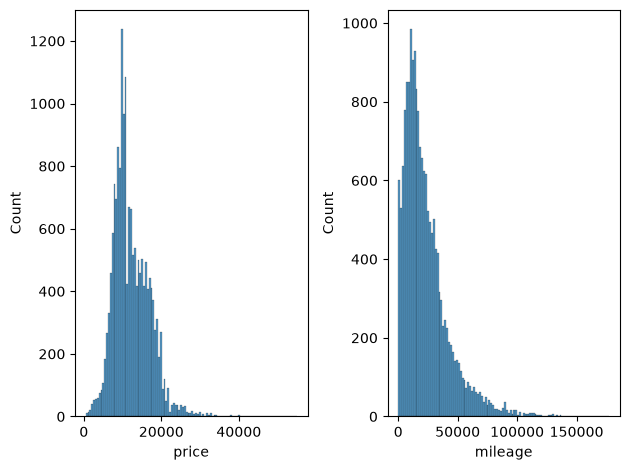

In [9]:
plt.subplot(1,2,1)
sns.histplot(new_df['price'])
plt.subplot(1,2,2)
sns.histplot(new_df['mileage'])
plt.tight_layout()

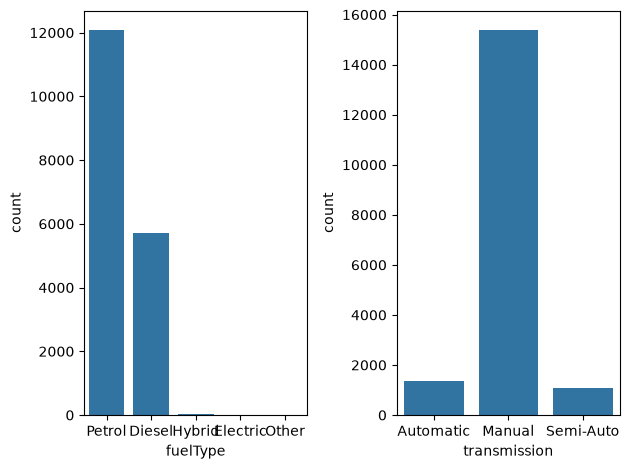

In [10]:
plt.subplot(1,2,1)
sns.countplot(data = new_df, x = 'fuelType')
plt.subplot(1,2,2)
sns.countplot(data = new_df, x = 'transmission')
plt.tight_layout()

<Axes: >

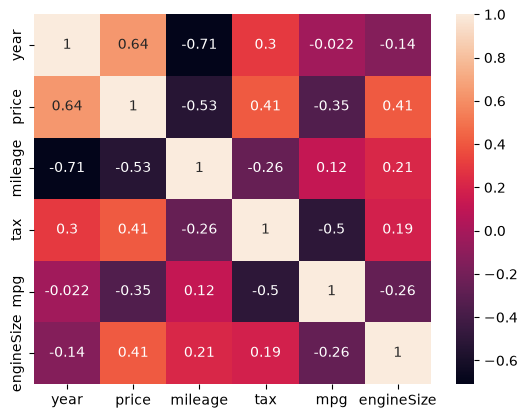

In [11]:
sns.heatmap(new_df.corr(numeric_only = True),annot = True)

Input Feature  : engineSize, mpg, tax, mileage, model, transmission

Output Feature : Price

In [12]:
categorical = new_df.select_dtypes(include='object').columns
print(categorical)

Index(['model', 'transmission', 'fuelType'], dtype='str')


In [13]:
encoded_df = pd.get_dummies(df)
encoded_df.head()

,year,price,mileage,tax,mpg,engineSize,model_B-MAX,model_C-MAX,model_EcoSport,model_Edge,...,model_Tourneo Custom,model_Transit Tourneo,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57.7,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,2018,14000,9083,150,57.7,1.0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,2017,13000,12456,150,57.7,1.0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2019,17500,10460,145,40.3,1.5,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2019,16500,1482,145,48.7,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [14]:
scalar = StandardScaler()
Scaled_df = pd.DataFrame(scalar.fit_transform(encoded_df),columns = encoded_df.columns)
Scaled_df.head()

,year,price,mileage,tax,mpg,engineSize,model_B-MAX,model_C-MAX,model_EcoSport,model_Edge,...,model_Tourneo Custom,model_Transit Tourneo,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.058959,-0.380998,0.591358,-0.020442,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,...,-0.062092,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.68932
1,0.552866,0.362875,-0.733359,0.591358,-0.020442,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.68932
2,0.065128,0.151958,-0.560132,0.591358,-0.020442,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.68932
3,1.040605,1.101082,-0.662640,0.510727,-1.738890,0.345070,-0.141978,-0.176538,-0.260658,-0.108227,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.68932
4,1.040605,0.890166,-1.123724,0.510727,-0.909294,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,...,-0.062092,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.68932
